In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from narwhals.selectors import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [17]:
df = pd.read_csv("PJME_hourly.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index("Datetime").sort_index()

In [22]:
df = df[~df.index.duplicated(keep="first")]

TARGET = "PJME_MW"
print(f"Rows: {len(df):,}  |  Range: {df.index.min()} -> {df.index.max()}")

Rows: 145,362  |  Range: 2002-01-01 01:00:00 -> 2018-08-03 00:00:00


In [23]:
def add_time_features(data):
    """Calendar features derived from the timestamp. These are SAFE: the hour
    or month of a future timestamp is always known in advance -> no leakage."""
    data = data.copy()
    idx = data.index
    data["hour"] = idx.hour
    data["dayofweek"] = idx.dayofweek
    data["quarter"] = idx.quarter
    data["month"] = idx.month
    data["year"] = idx.year
    data["dayofyear"] = idx.dayofyear
    data["dayofmonth"] = idx.day
    data["weekofyear"] = idx.isocalendar().week.astype(int)
    return data

In [25]:
df = add_time_features(df)

In [27]:
def add_lag_features(data, target):
    """Past values of the series. .shift(n) only looks BACKWARD, so no leakage.
    We use lags at ~1 year, ~2 years, ~3 years so the model can forecast far
    into the future without needing yesterday's value at prediction time."""
    data = data.copy()
    data["lag_1y"] = data[target].shift(364 * 24)   # ~1 year of hours
    data["lag_2y"] = data[target].shift(728 * 24)
    data["lag_3y"] = data[target].shift(1092 * 24)
    return data

In [28]:
df = add_lag_features(df, TARGET)

In [29]:
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_1y,lag_2y,lag_3y
Datetime,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,2,31,44429.0,44460.0,41920.0
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,2,31,42256.0,43375.0,41430.0
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,2,31,41210.0,41485.0,39990.0


In [30]:
SPLIT_DATE = "2015-01-01"
train = df.loc[df.index < SPLIT_DATE].copy()
test = df.loc[df.index >= SPLIT_DATE].copy()

FEATURES = [
    "hour", "dayofweek", "quarter", "month", "year",
    "dayofyear", "dayofmonth", "weekofyear",
    "lag_1y", "lag_2y", "lag_3y",
]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

In [31]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    early_stopping_rounds=50,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100)

[0]	validation_0-rmse:6250.59764	validation_1-rmse:6318.87940
[100]	validation_0-rmse:2753.53955	validation_1-rmse:3798.74524
[111]	validation_0-rmse:2702.08627	validation_1-rmse:3805.78414


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
test = test.copy()
test["prediction"] = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(test[TARGET], test["prediction"]))
mae = mean_absolute_error(test[TARGET], test["prediction"])
mape = np.mean(np.abs((test[TARGET] - test["prediction"]) / test[TARGET])) * 100

print(f"\nTest RMSE: {rmse:,.0f}")
print(f"Test MAE:  {mae:,.0f}")
print(f"Test MAPE: {mape:.2f}%")


Test RMSE: 3,774
Test MAE:  2,925
Test MAPE: 9.31%


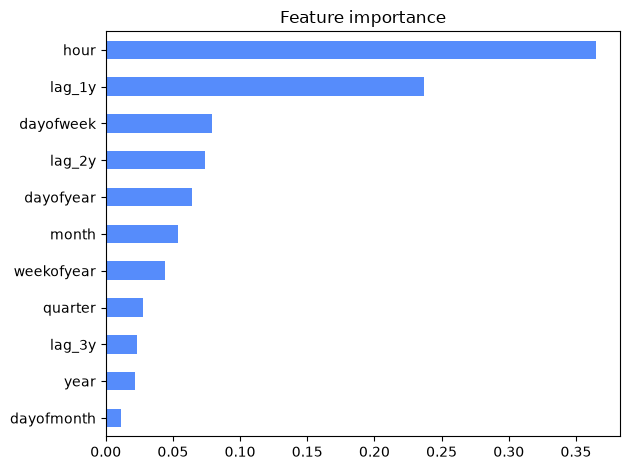

In [39]:
importance = pd.Series(model.feature_importances_, index=FEATURES)
importance.sort_values().plot(kind="barh", title="Feature importance")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

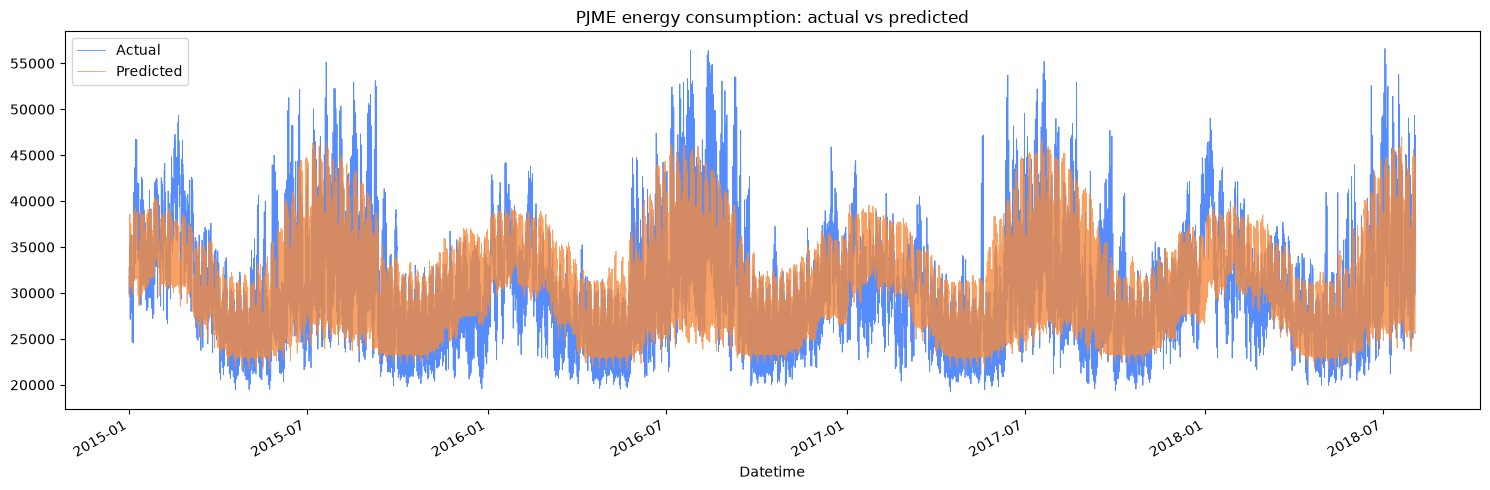

In [38]:
fig, ax = plt.subplots(figsize=(15, 5))
test[TARGET].plot(ax=ax, label="Actual", lw=0.6)
test["prediction"].plot(ax=ax, label="Predicted", lw=0.6, alpha=0.8)
ax.set_title("PJME energy consumption: actual vs predicted")
ax.legend()
plt.tight_layout()
plt.show

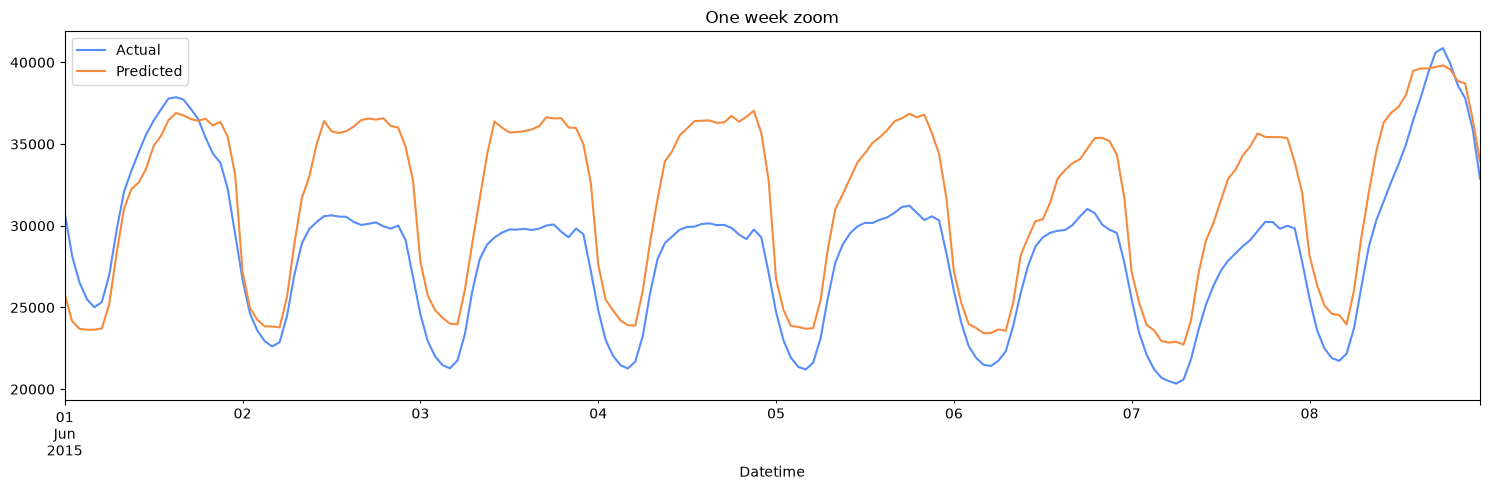

In [40]:
one_week = test.loc["2015-06-01":"2015-06-08"]
fig, ax = plt.subplots(figsize=(15, 5))
one_week[TARGET].plot(ax=ax, label="Actual")
one_week["prediction"].plot(ax=ax, label="Predicted")
ax.set_title("One week zoom")
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import r2_score
r2 = r2_score(test[TARGET], test["prediction"])
print(f"Test R²: {r2:.3f}")

Test R²: 0.658
